# Autocorrelation and Autoregressive Models

### Load required packages.

In [3]:
from pathlib import Path

import math
import numpy as np
import pandas as pd
import statsmodels.formula.api as sm
from statsmodels.tsa import tsatools 
from statsmodels.tsa import stattools
from statsmodels.graphics import tsaplots
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf
from dmba import regressionSummary
import warnings

import matplotlib.pylab as plt
%matplotlib inline

### Create templates for graph layout.

In [5]:
# Create a template for graph layout with partitions for data set. 
def Graph_Layout_Partition_Data():
    # Determine coordinates for drawing vertical lines and 
    # horizontal arrows on the chart.    
    one_month = pd.Timedelta('31 days')
    xtrain = (min(train_ts.index), max(train_ts.index) - one_month)
    xvalid = (min(valid_ts.index) + one_month, max(valid_ts.index) - one_month)
    xfuture = (max(valid_ts.index) + one_month, '2022')
    xtv = xtrain[1] + 0.7 * (xvalid[0] - xtrain[1])
    xvf = xvalid[1] + 1.0 * (xfuture[0] - xvalid[1])

    ax.axvline(x=xtv, ymin=0, ymax=1, color='black', linewidth=0.5)
    ax.axvline(x=xvf, ymin=0, ymax=1, color='black', linewidth=0.5)

    plt.annotate('', xy=('2013-12', 3300), xytext=('1991', 3300), 
              arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))
    plt.annotate('', xy=('2018-12', 3300), xytext=('2014-2', 3300), 
             arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))
    plt.annotate('', xy=('2021-12', 3300), xytext=('2019-2', 3300), 
             arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))

    # Input text on the arrows.
    ax.text('2001', 3330, 'Training')
    ax.text('2015-1', 3330, 'Validation')
    ax.text('2019-7', 3330, 'Future')

    # Create limits and axis labels.
    ax.set_xlim('1990', '2022')
    ax.set_ylim(1300, 3500)
    ax.set_xlabel('Time')
    ax.set_ylabel('Ridership (in 000s)')

# Create a template for graph layout with partitions for residuals. 
def Graph_Layout_Partition_Residuals():
    # Determine coordinates for drawing vertical lines and 
    # horizontal arrows on the chart.    
    one_month = pd.Timedelta('31 days')
    xtrain = (min(train_ts.index), max(train_ts.index) - one_month)
    xvalid = (min(valid_ts.index) + one_month, max(valid_ts.index) - one_month)
    xfuture = (max(valid_ts.index) + one_month, '2022')
    xtv = xtrain[1] + 0.7 * (xvalid[0] - xtrain[1])
    xvf = xvalid[1] + 1.0 * (xfuture[0] - xvalid[1])

    ax.axvline(x=xtv, ymin=0, ymax=1, color='black', linewidth=0.5)
    ax.axvline(x=xvf, ymin=0, ymax=1, color='black', linewidth=0.5)

    plt.annotate('', xy=('2013-12', 600), xytext=('1991', 600), 
              arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))
    plt.annotate('', xy=('2018-12', 600), xytext=('2014-2', 600), 
             arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))
    plt.annotate('', xy=('2021-12', 600), xytext=('2019-2', 600), 
             arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))

    # Input text on the arrows.
    ax.text('2001', 620, 'Training')
    ax.text('2015-1', 620, 'Validation')
    ax.text('2019-7', 620, 'Future')

    # Create limits and axis labels.
    ax.set_xlim('1990', '2022')
    ax.set_ylim(-600, 700)
    ax.set_xlabel('Time')
    ax.set_ylabel('Ridership (in 000s)')


# Create a template for graph layout with entire dataset and 12 periods 
# into future. 
def Graph_Layout_Entire_Data():
    # Determine coordinates for drawing vertical lines and horizontal 
    # arrows on the chart.
    one_month = pd.Timedelta('31 days')
    xridership = (min(ridership_ts.index), max(ridership_ts.index) - one_month)
    xfuture = (max(ridership_ts.index) + one_month, '2022')
    xvf = xridership[1] + 0.7 * (xfuture[0] - xridership[1])

    ax.axvline(x=xvf, ymin=0, ymax=1, color='black', linewidth=0.5)

    plt.annotate('', xy=('2018-12', 3300), xytext=('1991', 3300), 
              arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))
    plt.annotate('', xy=('2021-12', 3300), xytext=('2019-2', 3300), 
             arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))

    # Input text on the arrows.
    ax.text('2005', 3330, 'Training')
    ax.text('2019-7', 3330, 'Future')

    # Create limits and axis labels.
    ax.set_xlim('1990', '2022')
    ax.set_ylim(1300, 3500)
    ax.set_xlabel('Time')
    ax.set_ylabel('Ridership (in 000s)')
    

# Create a template for graph layout with entire data for residuals. 
def Graph_Layout_Entire_Data_Residuals():
    # Determine coordinates for drawing vertical lines and 
    # horizontal arrows on the chart.    
    one_month = pd.Timedelta('31 days')
    xridership = (min(ridership_ts.index), max(ridership_ts.index) - one_month)
    xfuture = (max(ridership_ts.index) + one_month, '2022')
    xvf = xridership[1] + 0.7 * (xfuture[0] - xridership[1])

    ax.axvline(x=xvf, ymin=0, ymax=1, color='black', linewidth=0.5)

    plt.annotate('', xy=('2018-12', 600), xytext=('1991', 600), 
             arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))
    plt.annotate('', xy=('2021-12', 600), xytext=('2019-2', 600), 
             arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))

    # Input text on the arrows.
    ax.text('2005', 620, 'Training')
    ax.text('2019-7', 620, 'Future')

    # Create limits and axis labels.
    ax.set_xlim('1990', '2022')
    ax.set_ylim(-600, 700)
    ax.set_xlabel('Time')
    ax.set_ylabel('Ridership (in 000s)')

### Create measures of forecast accuracy.

In [7]:
# Create forcast accuracy measures.
def Forecast_Accuracy(actual, forecast):
    
    # ME - mean error
    me = round(np.mean(actual - forecast),3) 
    
    # RMSE - root mean square error (RMSE)
    rmse = round((np.mean((actual - forecast)**2)**.5),3)  
   
    # MAE - mean absolute error
    mae = round(np.mean(np.abs(actual - forecast)),3)   
   
    # MPE - mean percentage error,%
    mpe = round(((np.mean((actual - forecast)/actual))*100),3) 
    
    # MAPE - mean absolute percentage error, %
    mape = round(((np.mean(np.abs((actual - forecast)/actual)))*100),3) 
    
    # Ignore unnecessary future warnings on ACF1. 
    warnings.filterwarnings('ignore')
    
    # ACF1 - autocorrelation of errors at lag 1
    acf1 = round((acf(actual - forecast)[1]),3)                 
    
    return({'ME':me, 'RMSE':rmse, 'MAE':mae, 
            'MPE':mpe, 'MAPE':mape, 'ACF1':acf1})

### Create time series data set and identify autocorrelation.

In [9]:
# Create Amtrak data frame.
Amtrak_data = pd.read_csv('Amtrak_comp.csv')

# Display the first 5 records of Amtrak data set.

# Convert the date information to a datetime object as monthly data.
Amtrak_data['Date'] = pd.to_datetime(Amtrak_data.Month)

# Convert data set to time series  data set. Name is used 
# to label the data.
ridership_ts = pd.Series(Amtrak_data.Ridership.values, 
                index=Amtrak_data.Date, name='Ridership')

# Define Amtrak time series frequency as month 'MS'. 
ridership_ts.index = pd.DatetimeIndex(ridership_ts.index, freq = 'MS')

# Display first 5 records of Amtrak time series data.
ridership_ts.head()


Date
1991-01-01    1708.917
1991-02-01    1620.586
1991-03-01    1972.715
1991-04-01    1811.665
1991-05-01    1974.964
Freq: MS, Name: Ridership, dtype: float64

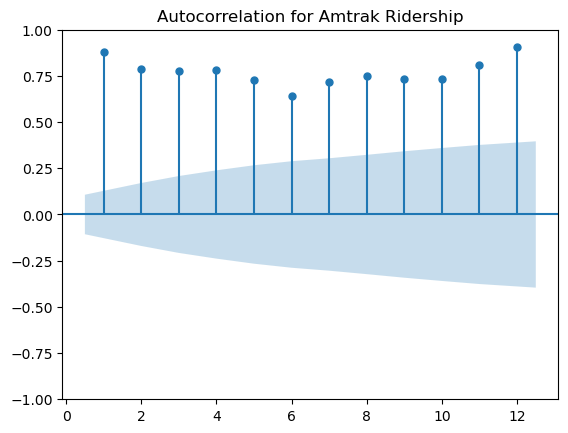

In [10]:
# Use plot_asf() function to identify autocorrelation and plot autocorrelation
# for different lags (up to maximum of 12).

# Display autocorrelation chart. 
# Using specific lags [1, ..., 12] will exclude lag=0. 
interval = [1,2,3,4,5,6,7,8,9,10,11,12]
tsaplots.plot_acf(ridership_ts, lags = interval)
plt.title('Autocorrelation for Amtrak Ridership')

plt.show()

### Create time series partition and autocorrelation for partition. 

In [12]:
# Define the numbers of months in the training and validation data sets,
# nTrain and nValid, respectively and create data partition, train_ts
# and valid_ts.
nValid = 60
nTrain = len(ridership_ts) - nValid
train_ts = ridership_ts[:nTrain]
valid_ts = ridership_ts[nTrain:]

# Create a time series dataframe with additional linear trend term (t) 
# and constant term (c) for entire data set. This will enable 
# to develop training and validation partition for trend and seasonality
# regression.
ridership_df = tsatools.add_trend(ridership_ts, trend='ct')
print('Entire Data Set with Trend and Constant')
print(ridership_df)

# Develop monthly index for ridership_df.
ridership_df['Month'] = ridership_df.index.month

# Partition the training data set using ridership_df and display it. 
train_df = ridership_df[:nTrain]
print(' ')
print('Training Data Set')
print(train_df)

# Partition the validation data set using ridership_df and display it. 
valid_df = ridership_df[nTrain:]
print(' ')
print('Validation Data Set')
print(' ')
print('Validation Data Set')
print(valid_df.head())
print('                 ...')
print(valid_df.tail())


Entire Data Set with Trend and Constant
            Ridership  const  trend
Date                               
1991-01-01   1708.917    1.0    1.0
1991-02-01   1620.586    1.0    2.0
1991-03-01   1972.715    1.0    3.0
1991-04-01   1811.665    1.0    4.0
1991-05-01   1974.964    1.0    5.0
...               ...    ...    ...
2018-08-01   2848.935    1.0  332.0
2018-09-01   2522.367    1.0  333.0
2018-10-01   2807.200    1.0  334.0
2018-11-01   2873.968    1.0  335.0
2018-12-01   2668.049    1.0  336.0

[336 rows x 3 columns]
 
Training Data Set
            Ridership  const  trend  Month
Date                                      
1991-01-01   1708.917    1.0    1.0      1
1991-02-01   1620.586    1.0    2.0      2
1991-03-01   1972.715    1.0    3.0      3
1991-04-01   1811.665    1.0    4.0      4
1991-05-01   1974.964    1.0    5.0      5
...               ...    ...    ...    ...
2013-08-01   2851.979    1.0  272.0      8
2013-09-01   2440.153    1.0  273.0      9
2013-10-01   2625.

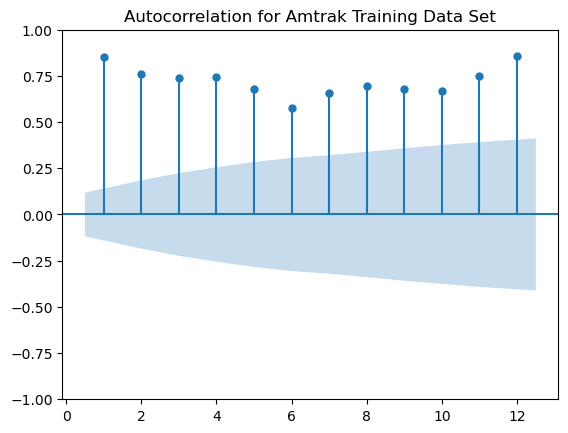

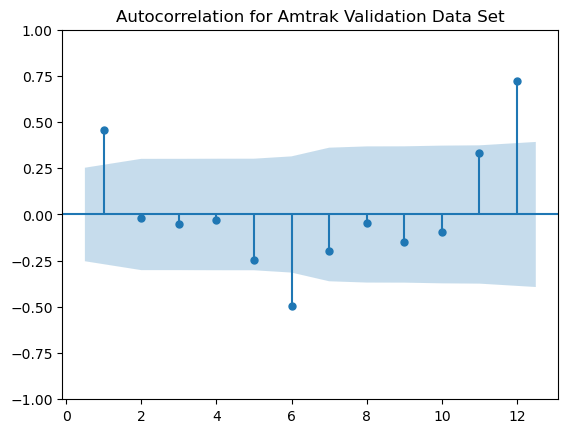

In [13]:
# Use plot_asf() function to identify autocorrelation for training and
# validation data sets, and plot autocorrelation for different lags 
# (up to maximum of 12).

# Display autocorrelation charts. 
# Using specific lags [1, ..., 12] from 
# interval = [1,2,3,4,5,6,7,8,9,10,11,12] will exclude lag=0.
tsaplots.plot_acf(train_ts, lags = interval)
plt.title('Autocorrelation for Amtrak Training Data Set')

tsaplots.plot_acf(valid_ts, lags = interval)
plt.title('Autocorrelation for Amtrak Validation Data Set')

plt.show()

### Fit regression model with linear trend and seasonality. Plot residuals and identify autocorrelation for residuals. 

In [15]:
# Use statsmodels' (sm) ols() function (ordinary least squares) to create 
# regression model with quadratic trend and seasonality for training data.
train_lin_season = sm.ols(formula='Ridership ~ trend \
                + C(Month)', data=train_df).fit()

# See summary of linear trend and seasonality model ans 
# associated parameters. 
print(' ')
print("Parameters for Linear Trend and Seasonality Regression")
print(train_lin_season.summary())

# Print fitted values from linear trend and seasonality model 
# for training data.
train_lin_season_fit = train_lin_season.fittedvalues
print(' ')
print('Linear Trend and Seasonality Fit for Training Data')
print(train_lin_season_fit)

# Apply predict() function to make forecast using quadratic trend and 
# seasonality model for validation period. 
train_lin_season_pred = train_lin_season.predict(valid_df)
print(' ')
print('Linear Trend and Seasonality Forecast for Validation Data')
print(train_lin_season_pred.head())
print('                 ...')
print(train_lin_season_pred.tail())


 
Parameters for Linear Trend and Seasonality Regression
                            OLS Regression Results                            
Dep. Variable:              Ridership   R-squared:                       0.846
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     120.5
Date:                Thu, 16 Jan 2025   Prob (F-statistic):           2.02e-99
Time:                        17:19:19   Log-Likelihood:                -1747.1
No. Observations:                 276   AIC:                             3520.
Df Residuals:                     263   BIC:                             3567.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

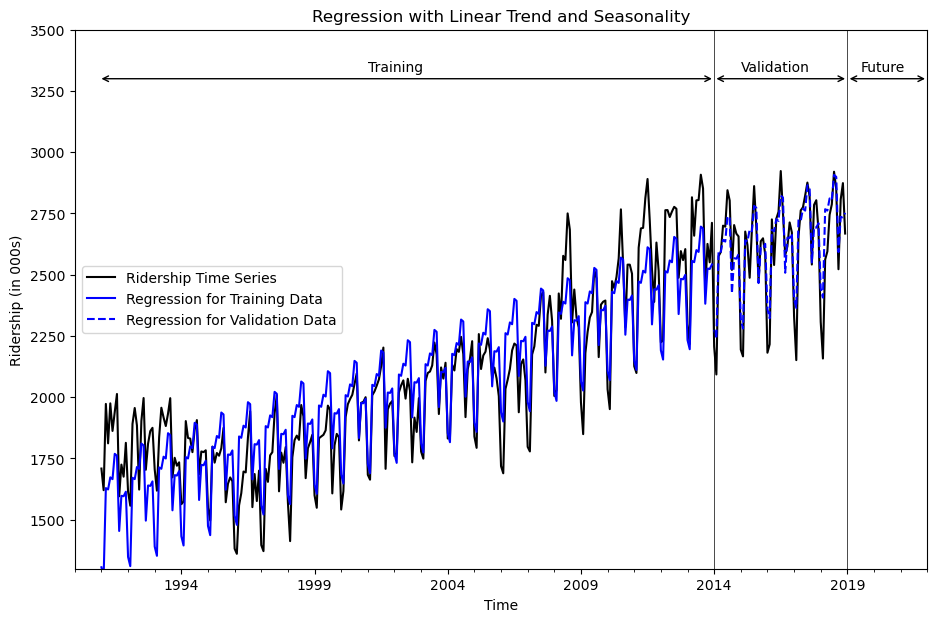

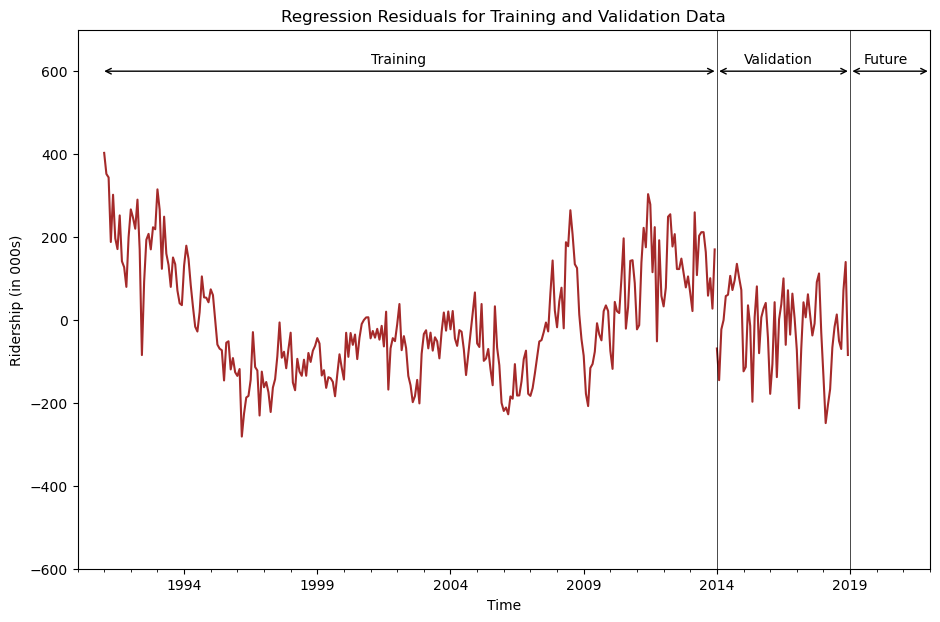

In [16]:
# Plot ts data, linear trend and seasonality data, and predictions
# for validation period.

# Plot entire data set that combines training and validation.
ax = ridership_ts.plot(color='black', linewidth=1.5, figsize=(11,7))

# Plot linear trend and seasonality model for training and valiation sets.
train_lin_season_fit.plot(ax = ax, color="blue", linewidth=1.5)
train_lin_season_pred.plot(ax = ax, color="blue", style='--', 
                             linewidth=1.5)

# Use template of graph layout for partitions. 
Graph_Layout_Partition_Data()

# Create graph legend and title.
ax.legend(['Ridership Time Series', 'Regression for Training Data', 
           'Regression for Validation Data'], 
           loc = 'center left')
plt.title('Regression with Linear Trend and Seasonality')


# Plot residuals of the predictions with linear trend and seasonality.
# Identify residuals for training and valiation partition.
train_lin_season_fit_res = train_lin_season.resid
train_lin_season_pred_res = valid_ts - train_lin_season_pred

# Plot training and validation residuals.
fig, ax = plt.subplots(figsize=(11, 7))
ax = train_lin_season_fit_res.plot(ax=ax, color='brown', 
                            linewidth=1.5, figsize=(11,7))
train_lin_season_pred_res.plot(ax = ax, color="brown", 
                            linewidth=1.5)

# Use template of graph layout for partitions. 
Graph_Layout_Partition_Residuals()

# Create graph title.
plt.title('Regression Residuals for Training and Validation Data')

plt.show()

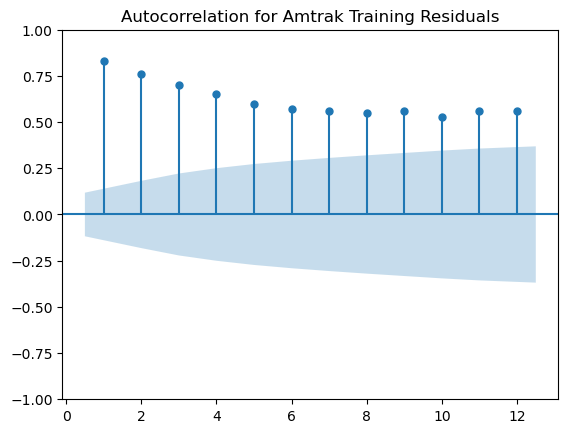

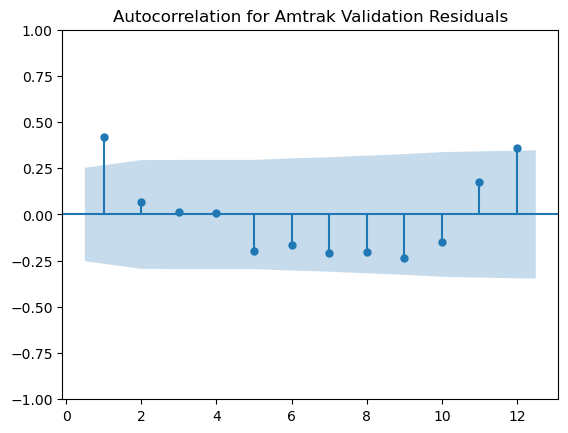

In [17]:
# Use plot_asf() function to identify autocorrelation for the model 
# residuals (training and validation sets), and plot autocorrelation 
# for different lags (up to maximum of 12).

# Display autocorrelation charts. 
# Using specific lags [1, ..., 12] will exclude lag=0.
tsaplots.plot_acf(train_lin_season_fit_res, lags = interval)
plt.title('Autocorrelation for Amtrak Training Residuals')

tsaplots.plot_acf(train_lin_season_pred_res, lags = interval)
plt.title('Autocorrelation for Amtrak Validation Residuals')

plt.show()

### Use ARIMA() function to create AR(1) model for training residuals. Create two-level model with quadratic trend and seasonality and AR(1) residuals.

In [19]:
# Use ARIMA() function to fit AR(1) model for training residulas.
# The ARIMA model of order=(1,0,0) gives an AR(1) model.
# Use summary() to identify parameters of AR(1) model. 
warnings.filterwarnings('ignore')
res_ar1 = ARIMA(train_lin_season_fit_res, order=(1, 0, 0), 
                freq='MS').fit()
print(res_ar1.summary())

# Display fitted residuals in training partition. 
print('AR(1) Residuals Forecast for Validation Data')
res_ar1_fit = res_ar1.fittedvalues
print(res_ar1_fit)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  276
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1574.006
Date:                Thu, 16 Jan 2025   AIC                           3154.012
Time:                        17:19:21   BIC                           3164.873
Sample:                    01-01-1991   HQIC                          3158.370
                         - 12-01-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.1728     30.814      0.395      0.693     -48.221      72.566
ar.L1          0.8592      0.031     28.080      0.000       0.799       0.919
sigma2      5234.3165    362.637     14.434      0.0

In [20]:
# Use forecast() function to make prediction of residuals in 
# validation set.
# res_ar1_pred, _, _ = res_ar1.forecast(nValid)
res_ar1_pred = res_ar1.forecast(nValid)
print(' ')
print('AR(1) Residuals Forecast for Validation Data')
res_ar1_pred

 
AR(1) Residuals Forecast for Validation Data


2014-01-01    147.849064
2014-02-01    128.741371
2014-03-01    112.324670
2014-04-01     98.219981
2014-05-01     86.101698
2014-06-01     75.690068
2014-07-01     66.744739
2014-08-01     59.059206
2014-09-01     52.456050
2014-10-01     46.782836
2014-11-01     41.908598
2014-12-01     37.720813
2015-01-01     34.122806
2015-02-01     31.031517
2015-03-01     28.375583
2015-04-01     26.093692
2015-05-01     24.133167
2015-06-01     22.448748
2015-07-01     21.001551
2015-08-01     19.758167
2015-09-01     18.689892
2015-10-01     17.772066
2015-11-01     16.983500
2015-12-01     16.305990
2016-01-01     15.723895
2016-02-01     15.223779
2016-03-01     14.794096
2016-04-01     14.424926
2016-05-01     14.107747
2016-06-01     13.835238
2016-07-01     13.601107
2016-08-01     13.399949
2016-09-01     13.227121
2016-10-01     13.078633
2016-11-01     12.951057
2016-12-01     12.841448
2017-01-01     12.747275
2017-02-01     12.666365
2017-03-01     12.596850
2017-04-01     12.537125


In [21]:
# Develop a data frame to demonstrate the training AR model results 
# vs. original training series, training regression model, 
# and its residuals.  

# Create residuals of regression residuals using the AR(1) model
# for regression residuals for training data.
res_ar1_res = res_ar1.resid
print(res_ar1_res)

# Create a table with Ridership training data, regression for training 
# data, training residuals, AR(1) model residuals for training data, 
# and residuals for regression residuals.
train_data_res_table = round(pd.concat([train_ts, train_lin_season_fit, 
                       train_lin_season_fit_res, res_ar1.fittedvalues, 
                       res_ar1_res], axis = 1), 3)

# Add column names in the table.
train_data_res_table.columns = ["Ridership", "Regression", "Residuals",
                          "AR.Model", "AR.Model.Residuals"]

# Display table.  
train_data_res_table


Date
1991-01-01    390.783034
1991-02-01      4.264998
1991-03-01     39.370064
1991-04-01   -108.941731
1991-05-01    138.723606
                 ...    
2013-08-01    -20.264546
2013-09-01    -83.510981
2013-10-01     48.667104
2013-11-01    -60.915466
2013-12-01    144.901126
Length: 276, dtype: float64


,Ridership,Regression,Residuals,AR.Model,AR.Model.Residuals
Date,,,,,
1991-01-01,1708.917,1305.961,402.956,12.173,390.783
1991-02-01,1620.586,1268.400,352.186,347.921,4.265
1991-03-01,1972.715,1629.044,343.671,304.301,39.370
1991-04-01,1811.665,1623.622,188.043,296.985,-108.942
1991-05-01,1974.964,1672.966,301.998,163.275,138.724
...,...,...,...,...,...
2013-08-01,2851.979,2688.601,163.378,183.642,-20.265
2013-09-01,2440.153,2381.581,58.572,142.083,-83.511
2013-10-01,2625.820,2525.115,100.705,52.038,48.667


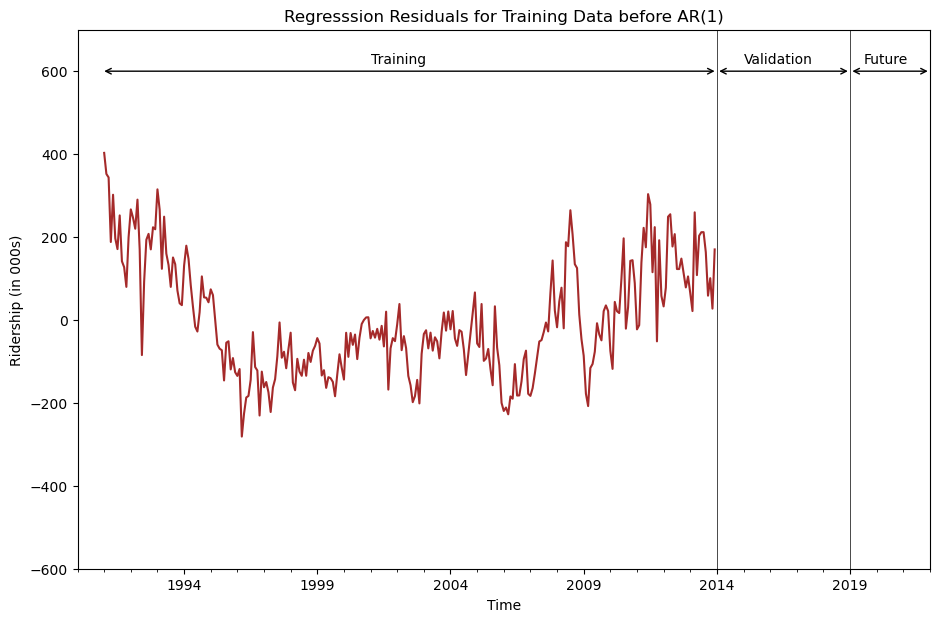

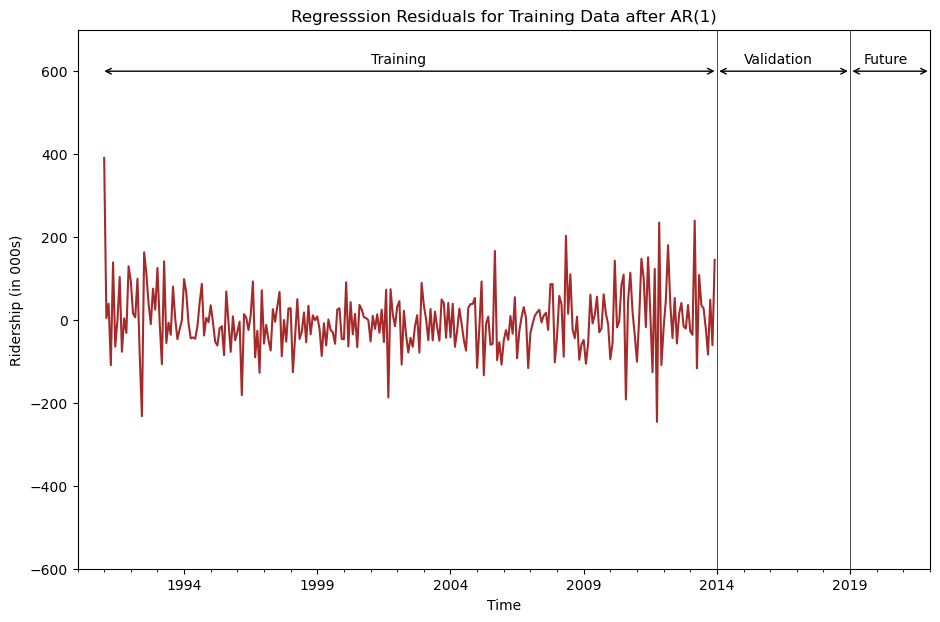

In [22]:
# Plot residuals of the predictions for training data before AR(1).
fig, ax = plt.subplots(figsize=(11, 7))
ax = train_lin_season_fit_res.plot(ax=ax, color='brown', 
                            linewidth=1.5, figsize=(11,7))

# Use template of graph layout for partitions. 
Graph_Layout_Partition_Residuals()

# Create graph title.
plt.title('Regresssion Residuals for Training Data before AR(1)')


# Plot residuals of the residuals for training data after AR(1).
fig, ax = plt.subplots(figsize=(11, 7))
ax = res_ar1_res.plot(ax=ax, color='brown', 
                            linewidth=1.5, figsize=(11,7))

# Use template of graph layout for partitions. 
Graph_Layout_Partition_Residuals()

# Create graph title.
plt.title('Regresssion Residuals for Training Data after AR(1)')

plt.show()

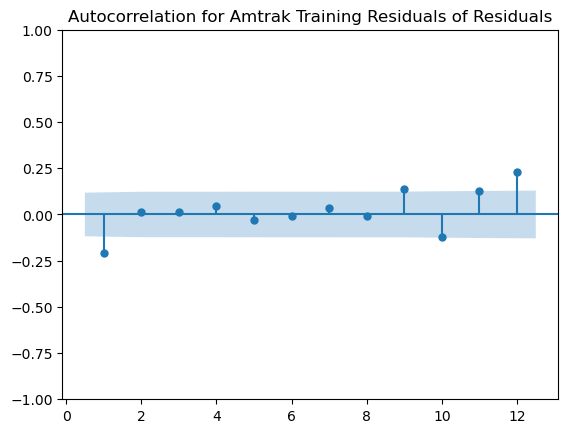

In [23]:
# Use plot_acf() function to identify autocorrelation for the 
# training residual of residuals and plot autocorrelation for 
# different lags (up to maximum of 12).

# Display autocorrelation chart. 
# Using specific lags [1, ..., 12] will exclude lag=0.
tsaplots.plot_acf(res_ar1_res, lags = interval)
plt.title('Autocorrelation for Amtrak Training Residuals of Residuals')

plt.show()

In [24]:
# Create two-level model's forecast with linear trend and seasonality 
# regression + AR(1) residuals for validation period.

# Create data table with validation data, regression forecast for validation 
# period, AR(1) residuals for validation, and two-level model's results. 
valid_two_level_pred = train_lin_season_pred + res_ar1_pred

# Convert res_ar1_pred rows and columns into one column.  
res_ar1_pred1 = valid_two_level_pred - train_lin_season_pred

valid_two_level_table = round(pd.concat([valid_ts, train_lin_season_pred,
                        res_ar1_pred1, valid_two_level_pred], axis = 1), 3)

# Add column names in the table.
valid_two_level_table.columns = ["Ridership", "Reg.Forecast",
                                 "AR(1)Forecast", "Combined Forecast"]

# Display table.  
valid_two_level_table


,Ridership,Reg.Forecast,AR(1)Forecast,Combined Forecast
Date,,,,
2014-01-01,2206.788,2275.614,147.849,2423.463
2014-02-01,2092.819,2238.053,128.741,2366.794
2014-03-01,2575.951,2598.697,112.325,2711.022
2014-04-01,2592.994,2593.275,98.220,2691.495
2014-05-01,2700.179,2642.618,86.102,2728.720
2014-06-01,2695.954,2635.223,75.690,2710.913
2014-07-01,2844.949,2738.599,66.745,2805.344
2014-08-01,2802.873,2730.760,59.059,2789.819
2014-09-01,2519.583,2423.740,52.456,2476.196


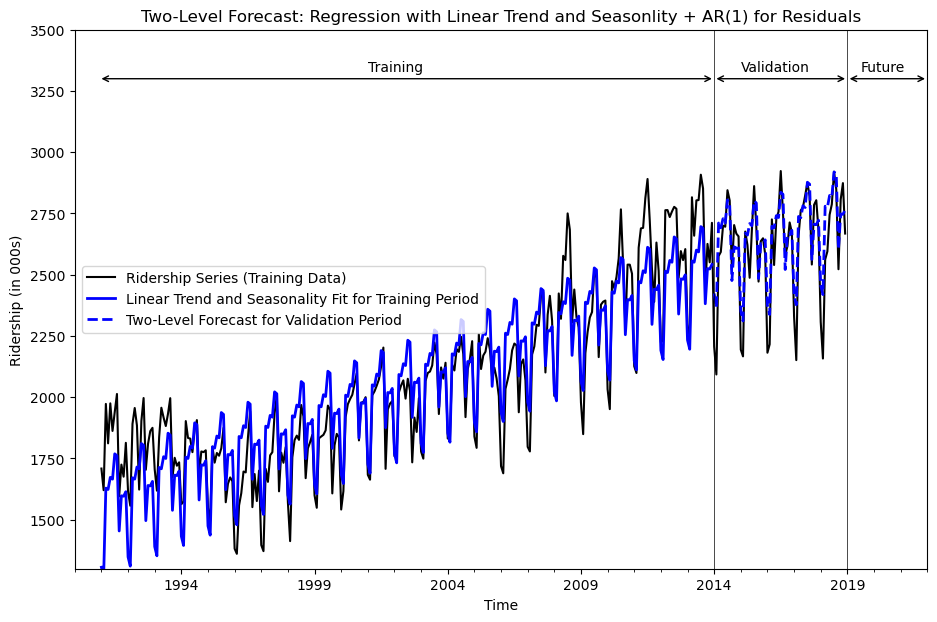

In [25]:
# Plot Ridership data, linear trend and seasonality model for training 
# partition, and two-level forecast (regression with liner 
# trend and seasonality and AR(1) for residuals) in validation period.

# Plot Ridership data set.
ax = ridership_ts.plot(color='black', linewidth=1.5, figsize=(11,7))

# Plot linear trend and seasonality model for training partition.
train_lin_season_fit.plot(ax = ax, color="blue", linewidth=2)
#train_trend_season_pred.plot(ax = ax, color="blue", style='--', 
#                             linewidth=1.5)



# Plot two-level forecast for validation period: regression linear 
# trend and seasonality and AR(1) for residuals.
valid_two_level_pred.plot(ax = ax, color="blue", style='--', 
                       linewidth=2)

# Use template of graph layout for partitions. 
Graph_Layout_Partition_Data()

# Create graph legend and title.
ax.legend(['Ridership Series (Training Data)', 
           'Linear Trend and Seasonality Fit for Training Period', 
           'Two-Level Forecast for Validation Period'],
           loc = 'center left')
plt.title('Two-Level Forecast: Regression with Linear Trend \
and Seasonlity + AR(1) for Residuals')

plt.show()

In [26]:
# Use Forecast_Accuracy(actual, forecast) function 
# defined in this file to identfiy common accuracy
# measures for two-level model with linear trend 
# and seasonality model and AR(1)residuals for 
# validation data.
print("Accuracy Measures for Linear Trend")
print(Forecast_Accuracy(valid_ts, valid_two_level_pred))

# Use Forecast_Accuracy(actual, forecast) function 
# defined in this file to identfiy common accuracy measures
# for for linear trend and seasonality model for 
# validation data.
print(' ')
print("Accuracy Measures for Quadratic Trend")
print(Forecast_Accuracy(valid_ts, train_lin_season_pred))

Accuracy Measures for Linear Trend
{'ME': -45.452, 'RMSE': 106.953, 'MAE': 81.222, 'MPE': -2.008, 'MAPE': 3.302, 'ACF1': 0.428}
 
Accuracy Measures for Quadratic Trend
{'ME': -17.224, 'RMSE': 95.541, 'MAE': 76.238, 'MPE': -0.892, 'MAPE': 3.04, 'ACF1': 0.42}


### Fit regression model with linear trend and seasonality for entire data set.  Forecast and plot data, and measure accuracy. Use two-level model with AR(1) residuals. 

In [28]:
# Use statsmodels' (sm) ols() function (ordinary least squares) 
# to create regression model with linear trend and seasonality
# model for entire data set. 
lin_season = sm.ols(formula='Ridership ~ trend + C(Month)', 
                      data=ridership_df).fit()

# See summary of linear trend and seasonality model ans associated 
# parameters. 
print(' ')
print("Parameters for Linear Trend and Seasonality Regression")
print(lin_season.summary())

# Print fitted values from linear trend and seasonality model for 
# entire data set.
lin_season_fit=lin_season.fittedvalues
print(' ')
print('Linear Trend and Seasonality Fit for Entire Data Set')
print(lin_season_fit)


 
Parameters for Linear Trend and Seasonality Regression
                            OLS Regression Results                            
Dep. Variable:              Ridership   R-squared:                       0.893
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     224.6
Date:                Thu, 16 Jan 2025   Prob (F-statistic):          1.05e-148
Time:                        17:19:24   Log-Likelihood:                -2109.0
No. Observations:                 336   AIC:                             4244.
Df Residuals:                     323   BIC:                             4294.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

In [29]:
# Create dataframe and time series with 12 future periods, and apply them
# to forecast with linear trend and seasonality.

# Create a dataframe with 12 periods into the future and add 
# regression linear trend and seasonality forecast for these 
# 12 periods according to the ridership_ts.

Month = pd.Series(['2019-01-01','2019-02-01','2019-03-01',
                   '2019-04-01','2019-05-01','2019-06-01',
                   '2019-07-01','2019-08-01','2019-09-01',
                   '2019-10-01','2019-11-01','2019-12-01'], 
                      name='Month')     
trend = pd.Series([337, 338, 339, 340, 341, 342, 343, 344, 
                   345, 346, 347, 348], name='trend')
idx = [337, 338, 339, 340, 341, 342, 343, 344, 
                 345, 346, 347, 348]
Month.index = idx
trend.index = idx
future12 = pd.concat([Month, trend], axis=1)
future12.index = idx
Month = pd.to_datetime(Month)

# Convert the date information to a datetime object 
# as monthly data.
future12['Date'] = pd.to_datetime(future12.Month, 
                      format='%Y-%m-%d')

# Convert dataframe column to time series (name is used 
# to label the data).
future12_ts = pd.Series(future12.trend.values, 
                 index=future12.Date, name='trend')

future12_df=tsatools.add_trend(future12_ts, trend='c')
future12_df['Month'] = future12_df.index.month

# Apply predict() function to make forecast using linear trend 
# and seasonality model for 12 future periods. 
lin_season_pred = lin_season.predict(future12_df)
print(' ')
print(lin_season_pred)


 
Date
2019-01-01    2456.301249
2019-02-01    2409.923142
2019-03-01    2792.287428
2019-04-01    2784.801499
2019-05-01    2836.938499
2019-06-01    2841.992856
2019-07-01    2951.144356
2019-08-01    2926.603142
2019-09-01    2628.541035
2019-10-01    2779.037392
2019-11-01    2783.324999
2019-12-01    2782.435678
dtype: float64


In [30]:
# Use ARIMA() function to fit AR(1) model for regression residulas. 
# The ARIMA model of order=(1,0,0) gives an AR(1) model.
# Identify regression residuals. 
lin_season_res = lin_season.resid

# Develop AR(1) model.
residual_ar1 = ARIMA(lin_season_res, order=(1, 0, 0), 
                     freq='MS').fit()

# Use summary() to identify parameters of AR(1) model. 
print(residual_ar1.summary())

# Use forecast() function to make prediction of residuals 
# in validation set.
residual_ar1_pred = residual_ar1.forecast(12)
print(' ')
print('AR(1) Residuals Forecast for 12 Future Months')
print(residual_ar1_pred)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  336
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1933.616
Date:                Thu, 16 Jan 2025   AIC                           3873.231
Time:                        17:19:24   BIC                           3884.683
Sample:                    01-01-1991   HQIC                          3877.796
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4044     22.601      0.195      0.845     -39.892      48.701
ar.L1          0.8162      0.030     26.857      0.000       0.757       0.876
sigma2      5816.3702    391.060     14.873      0.0

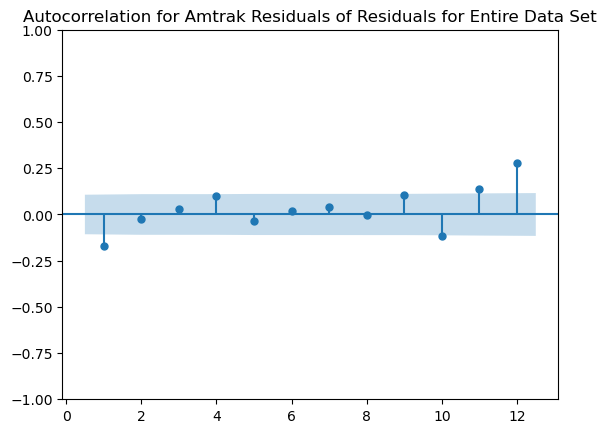

In [31]:
# Use Acf() function to identify autocorrealtion for the 
# residual of residuals and plot autocorrrelation for different 
# lags (up to maximum of 12).

# Display autocorrelation chart. 
# Using specific lags [1, ..., 12] will exclude lag=0.
residual_ar1_res = residual_ar1.resid
tsaplots.plot_acf(residual_ar1_res, lags = interval)
plt.title('Autocorrelation for Amtrak Residuals \
of Residuals for Entire Data Set')

plt.show()

In [32]:
# Create two-level model's forecast with linear trend and 
# seasonality regression + AR(1) residuals for 12 future 
# periods (months).
lin_season_ar1_pred = lin_season_pred + residual_ar1_pred
print('Two-Level Forecast for 12 Future Periods')
lin_season_ar1_pred


Two-Level Forecast for 12 Future Periods


Date
2019-01-01    2397.631661
2019-02-01    2362.847751
2019-03-01    2754.675000
2019-04-01    2754.912563
2019-05-01    2813.353329
2019-06-01    2823.552700
2019-07-01    2936.903463
2019-08-01    2915.789607
2019-09-01    2620.524844
2019-10-01    2773.304341
2019-11-01    2779.455403
2019-12-01    2780.086998
dtype: float64

In [33]:
# Create a data table with quadratic trend and seasonal forecast 
# for 12 future periods, AR(1) model for residuals for 12 future 
# periods, and combined two-level forecast for 12 future periods.  

# Convert res_ar1_pred rows and columns into one column.  
residual_ar1_pred1 = lin_season_ar1_pred - lin_season_pred

two_level_table_12_months = round(pd.concat([lin_season_pred,
        residual_ar1_pred1, lin_season_ar1_pred], axis = 1), 3)

# Add column names in the table.
two_level_table_12_months.columns = ["Reg.Forecast",
                "AR(1)Forecast", "Combined Forecast"]

# Print table.  
two_level_table_12_months

,Reg.Forecast,AR(1)Forecast,Combined Forecast
Date,,,
2019-01-01,2456.301,-58.670,2397.632
2019-02-01,2409.923,-47.075,2362.848
2019-03-01,2792.287,-37.612,2754.675
2019-04-01,2784.801,-29.889,2754.913
2019-05-01,2836.938,-23.585,2813.353
2019-06-01,2841.993,-18.440,2823.553
2019-07-01,2951.144,-14.241,2936.903
2019-08-01,2926.603,-10.814,2915.790
2019-09-01,2628.541,-8.016,2620.525


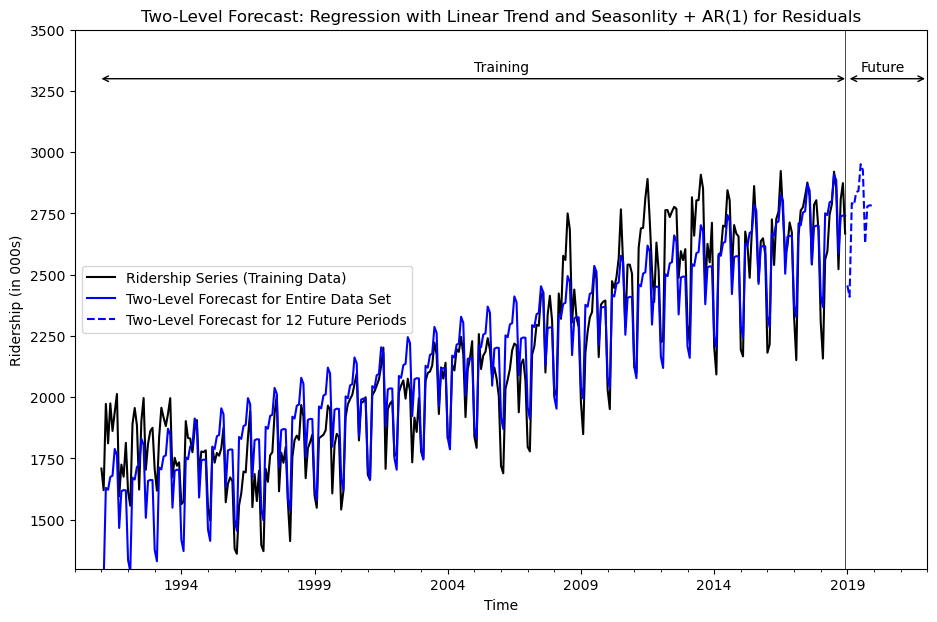

In [34]:
# Plot ts data, linear trend and seasonality model for training 
# period (entire data set), and forecast for 12 future periods 
# (months).

# Plot entire data set.
ax = ridership_ts.plot(color='black', linewidth=1.5, figsize=(11,7))

# Plot linear trend and seasonality model for entie data set.
lin_season_fit.plot(ax = ax, color="blue", linewidth=1.5)
lin_season_pred.plot(ax = ax, color="blue", style='--', 
                       linewidth=1.5)

# Use template of graph layout for entire data set. 
Graph_Layout_Entire_Data()

# Create graph legend and title.
ax.legend(['Ridership Series (Training Data)', 
           'Two-Level Forecast for Entire Data Set', 
           'Two-Level Forecast for 12 Future Periods'],
           loc = 'center left')
plt.title('Two-Level Forecast: Regression with Linear Trend \
and Seasonlity + AR(1) for Residuals')

plt.show()

### Compare accuracy measures of regression forecast with linear trend and seasonality for the entire data set with accuracy measures of naive forecast and seasonal naive forecast for entire data set. 

In [36]:
# Generate naive and seasonal naive forecasts for entire data set 
# to compare with HW model for entire data set.

# Take the previous value of ridership_ts[:-1] and use it as naive 
# forecast for entire data.
ridership_naive_pred = pd.Series(ridership_ts[:-1].values, 
                        index=ridership_ts[1:].index)
print('Naive Forecast for Entire Data Set')
print(ridership_naive_pred)

# Generate seasonal naive forecast for entire data set. 
# Take 12 previous periods of ridership_ts[:-12] and use 
# it as seasonal naive forecast for entire data.
ridership_snaive_pred = pd.Series(ridership_ts[:-12].values, 
                        index=ridership_ts[12:].index)
print(" ")
print('Seasonal Naive Forecast for Entire Data Set')
print(ridership_snaive_pred)

Naive Forecast for Entire Data Set
Date
1991-02-01    1708.917
1991-03-01    1620.586
1991-04-01    1972.715
1991-05-01    1811.665
1991-06-01    1974.964
                ...   
2018-08-01    2920.412
2018-09-01    2848.935
2018-10-01    2522.367
2018-11-01    2807.200
2018-12-01    2873.968
Freq: MS, Length: 335, dtype: float64
 
Seasonal Naive Forecast for Entire Data Set
Date
1992-01-01    1708.917
1992-02-01    1620.586
1992-03-01    1972.715
1992-04-01    1811.665
1992-05-01    1974.964
                ...   
2018-08-01    2819.838
2018-09-01    2541.622
2018-10-01    2785.149
2018-11-01    2804.107
2018-12-01    2680.541
Freq: MS, Length: 324, dtype: float64


In [37]:
# Use Forecast_Accuracy(actual, forecast) function 
# defined in this file to identfiy common accuracy
# measures for two-level model with linear trend 
# and seasonality model and AR(1) residuals for 
# entire data set.
lin_season_ar1_fit = lin_season_fit + residual_ar1.fittedvalues 

print('Accuracy Measures for Two-Level Model: \
Linear Trend and Seasonality Model + AR(1) Model')
print(Forecast_Accuracy(ridership_ts, lin_season_ar1_fit))

# Use Forecast_Accuracy(actual, forecast) function 
# defined in this file to identfiy common accuracy measures
# for for linear trend and seasonality model for 
# entire data set.
print(' ')
print("Accuracy Measures for Linear Trend and Seasonality")
print(Forecast_Accuracy(ridership_ts, lin_season_fit))

# Use Forecast_Accuracy(actual, forecast) function 
# defined in this file to identfiy common accuracy measures 
# for seasonal naive forecast for entire data set.
print("  ")
print("       Accuracy Measures for Seasonal Naive Forecast")
print(Forecast_Accuracy(ridership_ts[12:], ridership_snaive_pred))

# Use Forecast_Accuracy(actual, forecast) function 
# defined in this file to identfiy common accuracy measures 
# for naive forecast for entire data set.
print("  ")
print("       Accuracy Measures for Naive Forecast")
print(Forecast_Accuracy(ridership_ts[12:], ridership_naive_pred))

Accuracy Measures for Two-Level Model: Linear Trend and Seasonality Model + AR(1) Model
{'ME': -0.997, 'RMSE': 78.427, 'MAE': 58.443, 'MPE': -0.163, 'MAPE': 2.772, 'ACF1': -0.172}
 
Accuracy Measures for Linear Trend and Seasonality
{'ME': -0.0, 'RMSE': 128.744, 'MAE': 103.733, 'MPE': -0.33, 'MAPE': 5.103, 'ACF1': 0.793}
  
       Accuracy Measures for Seasonal Naive Forecast
{'ME': 31.113, 'RMSE': 116.076, 'MAE': 93.101, 'MPE': 1.26, 'MAPE': 4.375, 'ACF1': 0.631}
  
       Accuracy Measures for Naive Forecast
{'ME': 2.636, 'RMSE': 191.489, 'MAE': 139.351, 'MPE': -0.302, 'MAPE': 6.664, 'ACF1': nan}
